In [37]:
# 환경설정
!pip install selenium webdriver-manager
import os
import platform
import time
import warnings
from pathlib import Path
import re
from urllib.parse import urljoin, urlparse
import requests
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\JEON YUNA\my-first\ai-data-bootcamp\D011\환율과 코스피\d009_outputs


### 데이터 가져오기(1) - 환율

In [38]:
# 환율, 날짜 값 어디있는지 확인
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

url = "https://ecos.bok.or.kr/#/Short/1908cf"
driver.get(url)
time.sleep(5)

html_new = driver.page_source
soup_new = BeautifulSoup(html_new, 'html.parser')
rows_new = soup_new.find_all('tr')
print(f"행 개수: {len(rows_new)}")

for i, row in enumerate(rows_new):
    tds = row.find_all('td')
    print(f"행 {i}: td 개수 = {len(tds)}")

행 개수: 22
행 0: td 개수 = 0
행 1: td 개수 = 1
행 2: td 개수 = 0
행 3: td 개수 = 1
행 4: td 개수 = 1
행 5: td 개수 = 0
행 6: td 개수 = 245
행 7: td 개수 = 0
행 8: td 개수 = 245
행 9: td 개수 = 0
행 10: td 개수 = 4
행 11: td 개수 = 0
행 12: td 개수 = 4
행 13: td 개수 = 0
행 14: td 개수 = 0
행 15: td 개수 = 0
행 16: td 개수 = 0
행 17: td 개수 = 1
행 18: td 개수 = 0
행 19: td 개수 = 0
행 20: td 개수 = 3
행 21: td 개수 = 1


In [ ]:
# 데이터 가져와보기
tds_6 = [td.get_text(strip=True) for td in rows_new[6].find_all('td')]
tds_8 = [td.get_text(strip=True) for td in rows_new[8].find_all('td')]

print("행6 처음 5개:", tds_6[:5])
print("행8 처음 5개:", tds_8[:5])

행6 처음 5개: ['1,367.20', '1,377.90', '1,382.00', '1,391.00', '1,383.10']
행8 처음 5개: ['2025/07/24', '2025/07/25', '2025/07/28', '2025/07/29', '2025/07/30']


In [40]:
# 데이터프레임으로 만들기
df_exchange= pd.DataFrame({
    '날짜': tds_8,
    '원달러_종가': tds_6
})

print(df_exchange_new.shape)
print(df_exchange_new.head())
print(df_exchange_new.tail())

(245, 2)
           날짜    원달러_종가
0  2025/07/24  1,367.20
1  2025/07/25  1,377.90
2  2025/07/28  1,382.00
3  2025/07/29  1,391.00
4  2025/07/30  1,383.10
             날짜    원달러_종가
240  2026/07/20  1,478.40
241  2026/07/21  1,473.40
242  2026/07/22  1,480.10
243  2026/07/23  1,466.80
244  2026/07/24  1,466.60


In [41]:
# csv로 저장하기
df_exchange.to_csv('exchange_rate.csv', index=False, encoding='utf-8-sig')
print('저장 완료: exchange_rate.csv')

저장 완료: exchange_rate.csv


### 데이터 가져오기(2) - 코스피, 코스닥, 외국인 순매수 데이터

In [ ]:
# 페이지 확인하기
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

url = "https://ecos.bok.or.kr/#/Short/1af56b"
driver.get(url)

time.sleep(5)

html_market = driver.page_source
print("페이지 길이:", len(html_market))
print("KOSPI지수" in html_market)

페이지 길이: 468609
True


In [ ]:
# 값들 위치 확인하기
soup_market = BeautifulSoup(html_market, 'html.parser')
rows_market = soup_market.find_all('tr')
print(f"행 개수: {len(rows_market)}")

for i, row in enumerate(rows_market):
    tds = row.find_all('td')
    print(f"행 {i}: td 개수 = {len(tds)}")

행 개수: 31
행 0: td 개수 = 0
행 1: td 개수 = 1
행 2: td 개수 = 0
행 3: td 개수 = 1
행 4: td 개수 = 1
행 5: td 개수 = 0
행 6: td 개수 = 245
행 7: td 개수 = 245
행 8: td 개수 = 245
행 9: td 개수 = 245
행 10: td 개수 = 0
행 11: td 개수 = 245
행 12: td 개수 = 0
행 13: td 개수 = 4
행 14: td 개수 = 4
행 15: td 개수 = 4
행 16: td 개수 = 4
행 17: td 개수 = 0
행 18: td 개수 = 4
행 19: td 개수 = 0
행 20: td 개수 = 0
행 21: td 개수 = 0
행 22: td 개수 = 0
행 23: td 개수 = 0
행 24: td 개수 = 0
행 25: td 개수 = 0
행 26: td 개수 = 1
행 27: td 개수 = 0
행 28: td 개수 = 0
행 29: td 개수 = 3
행 30: td 개수 = 1


In [ ]:
# 더 자세히 보기
target_rows = [6, 7, 8, 9, 11]

for r in target_rows:
    tds = [td.get_text(strip=True) for td in rows_market[r].find_all('td')]
    print(f"행 {r} 처음 5개:", tds[:5])
    print()

행 6 처음 5개: ['3,190.45', '3,196.05', '3,209.52', '3,230.57', '3,254.47']

행 7 처음 5개: ['7,431', '2,687', '4,802', '6,047', '5,801']

행 8 처음 5개: ['809.89', '806.95', '804.40', '804.45', '803.67']

행 9 처음 5개: ['372', '929', '-155', '-56', '455']

행 11 처음 5개: ['2025/07/24', '2025/07/25', '2025/07/28', '2025/07/29', '2025/07/30']



In [42]:
# 데이터프레임으로 만들기
날짜_텍스트 = [td.get_text(strip=True) for td in rows_market[11].find_all('td')]
코스피지수 = [td.get_text(strip=True) for td in rows_market[6].find_all('td')]
코스피외국인순매수 = [td.get_text(strip=True) for td in rows_market[7].find_all('td')]
코스닥지수 = [td.get_text(strip=True) for td in rows_market[8].find_all('td')]
코스닥외국인순매수 = [td.get_text(strip=True) for td in rows_market[9].find_all('td')]

df_market_extra = pd.DataFrame({
    '날짜': 날짜_텍스트,
    '코스피지수': 코스피지수,
    '코스피외국인순매수': 코스피외국인순매수,
    '코스닥지수': 코스닥지수,
    '코스닥외국인순매수': 코스닥외국인순매수
})

print(df_market_extra.shape)
print(df_market_extra.head())
print(df_market_extra.tail())

(245, 5)
           날짜     코스피지수 코스피외국인순매수   코스닥지수 코스닥외국인순매수
0  2025/07/24  3,190.45     7,431  809.89       372
1  2025/07/25  3,196.05     2,687  806.95       929
2  2025/07/28  3,209.52     4,802  804.40      -155
3  2025/07/29  3,230.57     6,047  804.45       -56
4  2025/07/30  3,254.47     5,801  803.67       455
             날짜     코스피지수 코스피외국인순매수   코스닥지수 코스닥외국인순매수
240  2026/07/20  6,516.27     5,272  749.64      -560
241  2026/07/21  6,747.95     3,087  753.34    -1,369
242  2026/07/22  6,797.70    26,299  751.09      -842
243  2026/07/23  7,096.89    21,487  790.28     1,681
244  2026/07/24  6,690.62   -32,852  748.22    -1,132


In [43]:
# csv로 저장하기
df_market_extra.to_csv('market_extra.csv', index=False, encoding='utf-8-sig')
print('저장 완료: market_extra.csv')

저장 완료: market_extra.csv


### 데이터 가져오고, 정제하기

In [46]:
# 데이터 불러와보기
df_exchange = pd.read_csv('exchange_rate.csv')
df_market_extra = pd.read_csv('market_extra.csv')

print(df_exchange.shape)
print(df_market_extra.shape)

print(df_exchange.columns.tolist())
print(df_market_extra.columns.tolist())

(245, 2)
(245, 5)
['날짜', '원달러_종가']
['날짜', '코스피지수', '코스피외국인순매수', '코스닥지수', '코스닥외국인순매수']


In [47]:
# 두 개 데이터프레임 날짜 기준으로 병합하기
final_all = df_exchange.merge(df_market_extra, on='날짜', how='outer')
print(final_all.shape)
print(final_all.head())
print(final_all.isnull().sum())

(245, 6)
           날짜    원달러_종가     코스피지수 코스피외국인순매수   코스닥지수 코스닥외국인순매수
0  2025/07/24  1,367.20  3,190.45     7,431  809.89       372
1  2025/07/25  1,377.90  3,196.05     2,687  806.95       929
2  2025/07/28  1,382.00  3,209.52     4,802  804.40      -155
3  2025/07/29  1,391.00  3,230.57     6,047  804.45       -56
4  2025/07/30  1,383.10  3,254.47     5,801  803.67       455
날짜           0
원달러_종가       1
코스피지수        1
코스피외국인순매수    1
코스닥지수        1
코스닥외국인순매수    1
dtype: int64


In [48]:
# dtype 변경하기, 날짜는 str->datetime / 숫자는 str->float로
final_all['날짜'] = pd.to_datetime(final_all['날짜'], format='%Y/%m/%d')

numeric_cols = ['원달러_종가', '코스피지수', '코스피외국인순매수', '코스닥지수', '코스닥외국인순매수']
for col in numeric_cols:
    final_all[col] = final_all[col].astype(str).str.replace(',', '').astype(float)

print(final_all.dtypes)

날짜           datetime64[us]
원달러_종가              float64
코스피지수               float64
코스피외국인순매수           float64
코스닥지수               float64
코스닥외국인순매수           float64
dtype: object


In [49]:
# 결측치 지우기 (12/31일 데이터 값 비어있음)
final_all = final_all.dropna()
print(final_all.shape)

(244, 6)


In [ ]:
# 이제 결측치 하나도 없음
print(final_all.isnull().sum())

날짜           0
원달러_종가       0
코스피지수        0
코스피외국인순매수    0
코스닥지수        0
코스닥외국인순매수    0
dtype: int64


### 분석, 시각화하기

In [51]:
# 질문에 답할 때 필요한 값들 만들기

# 환율 vs 코스피
corr_q1 = final_all['원달러_종가'].corr(final_all['코스피지수'])
print(f"[Q1] 환율 vs 코스피 지수 상관계수: {corr_q1:.3f}")

# 환율 vs 코스닥
corr_q2 = final_all['원달러_종가'].corr(final_all['코스닥지수'])
print(f"[Q2] 환율 vs 코스닥 지수 상관계수: {corr_q2:.3f}")

# 외국인 순매수(유가증권시장) vs 코스피 지수
corr_q3 = final_all['코스피외국인순매수'].corr(final_all['코스피지수'])
print(f"[Q3-1] 외국인 순매수(유가증권) vs 코스피 지수 상관계수: {corr_q3:.3f}")

# 외국인 순매수(유가증권시장) vs 환율
corr_q4 = final_all['코스피외국인순매수'].corr(final_all['원달러_종가'])
print(f"[Q4-1] 외국인 순매수(유가증권) vs 환율 상관계수: {corr_q4:.3f}")

# 외국인 순매수(코스닥) vs 코스닥 지수
corr_q3_2 = final_all['코스닥외국인순매수'].corr(final_all['코스닥지수'])
print(f"[Q3-2] 외국인 순매수(코스닥) vs 코스닥 지수 상관계수: {corr_q3_2:.3f}")

# [Q4-2] 외국인 순매수(코스닥) vs 환율
corr_q4_2 = final_all['코스닥외국인순매수'].corr(final_all['원달러_종가'])
print(f"[Q4-2] 외국인 순매수(코스닥) vs 환율 상관계수: {corr_q4_2:.3f}")

[Q1] 환율 vs 코스피 지수 상관계수: 0.815
[Q2] 환율 vs 코스닥 지수 상관계수: 0.452
[Q3-1] 외국인 순매수(유가증권) vs 코스피 지수 상관계수: -0.419
[Q4-1] 외국인 순매수(유가증권) vs 환율 상관계수: -0.414
[Q3-2] 외국인 순매수(코스닥) vs 코스닥 지수 상관계수: 0.085
[Q4-2] 외국인 순매수(코스닥) vs 환율 상관계수: 0.020


In [54]:
plt.rcParams['font.family'] = 'Malgun Gothic'

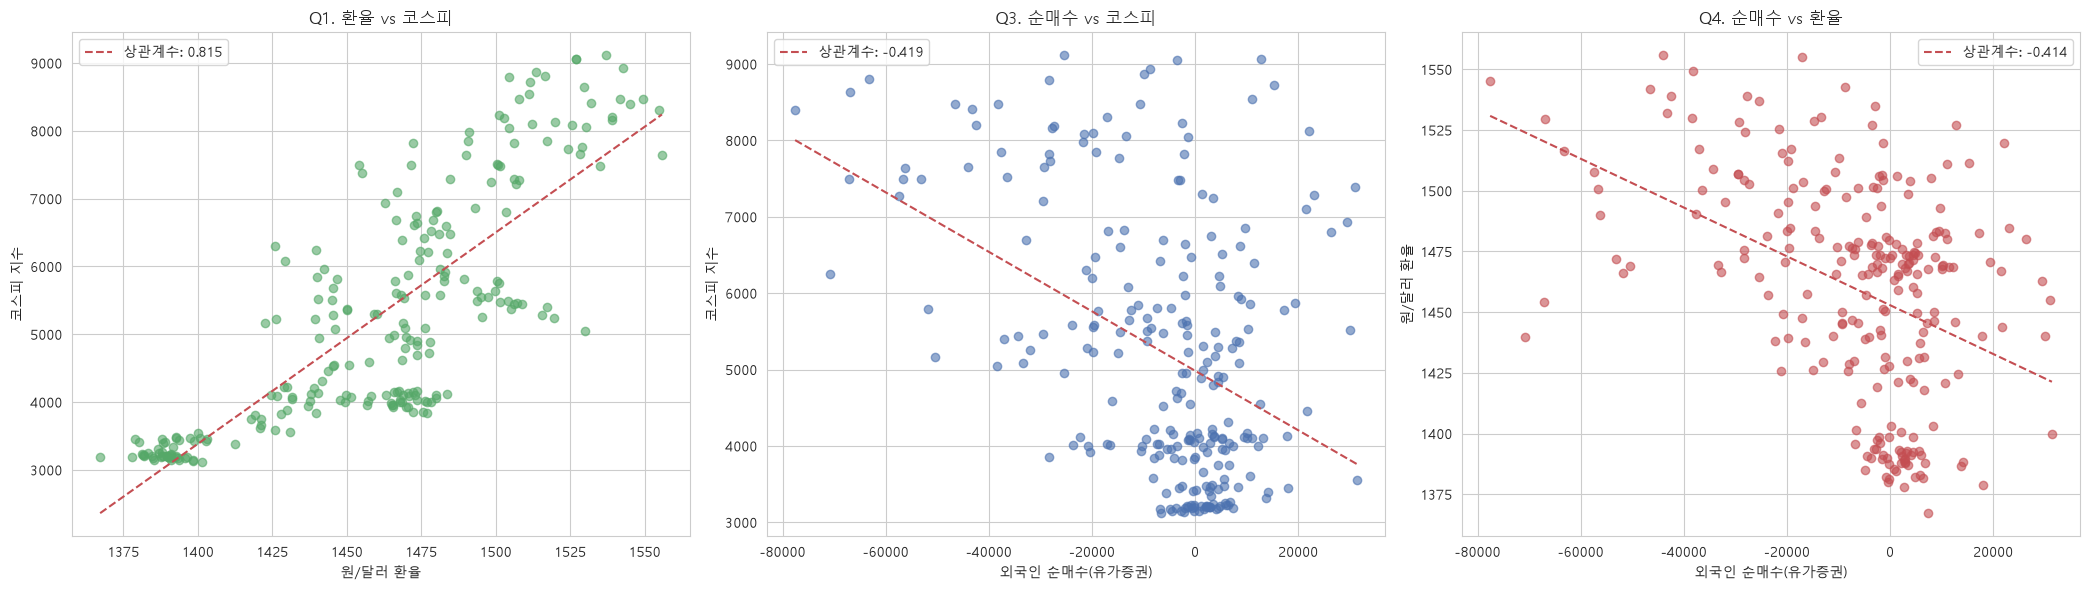

In [55]:
# 코스피 관련 그래프 그리기 (Q1, Q3-1, Q4-1)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

def plot_on_ax(ax, x, y, xlabel, ylabel, title, color):
    ax.scatter(final_all[x], final_all[y], alpha=0.6, color=color)
    corr = final_all[x].corr(final_all[y])
    z = np.polyfit(final_all[x], final_all[y], 1)
    p = np.poly1d(z)
    x_line = np.linspace(final_all[x].min(), final_all[x].max(), 100)
    ax.plot(x_line, p(x_line), color='#C44E52', linestyle='--', label=f'상관계수: {corr:.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plot_on_ax(axes[0], '원달러_종가', '코스피지수', '원/달러 환율', '코스피 지수', 'Q1. 환율 vs 코스피', '#55A868')
plot_on_ax(axes[1], '코스피외국인순매수', '코스피지수', '외국인 순매수(유가증권)', '코스피 지수', 'Q3. 순매수 vs 코스피', '#4C72B0')
plot_on_ax(axes[2], '코스피외국인순매수', '원달러_종가', '외국인 순매수(유가증권)', '원/달러 환율', 'Q4. 순매수 vs 환율', '#C44E52')

plt.tight_layout()
plt.show()

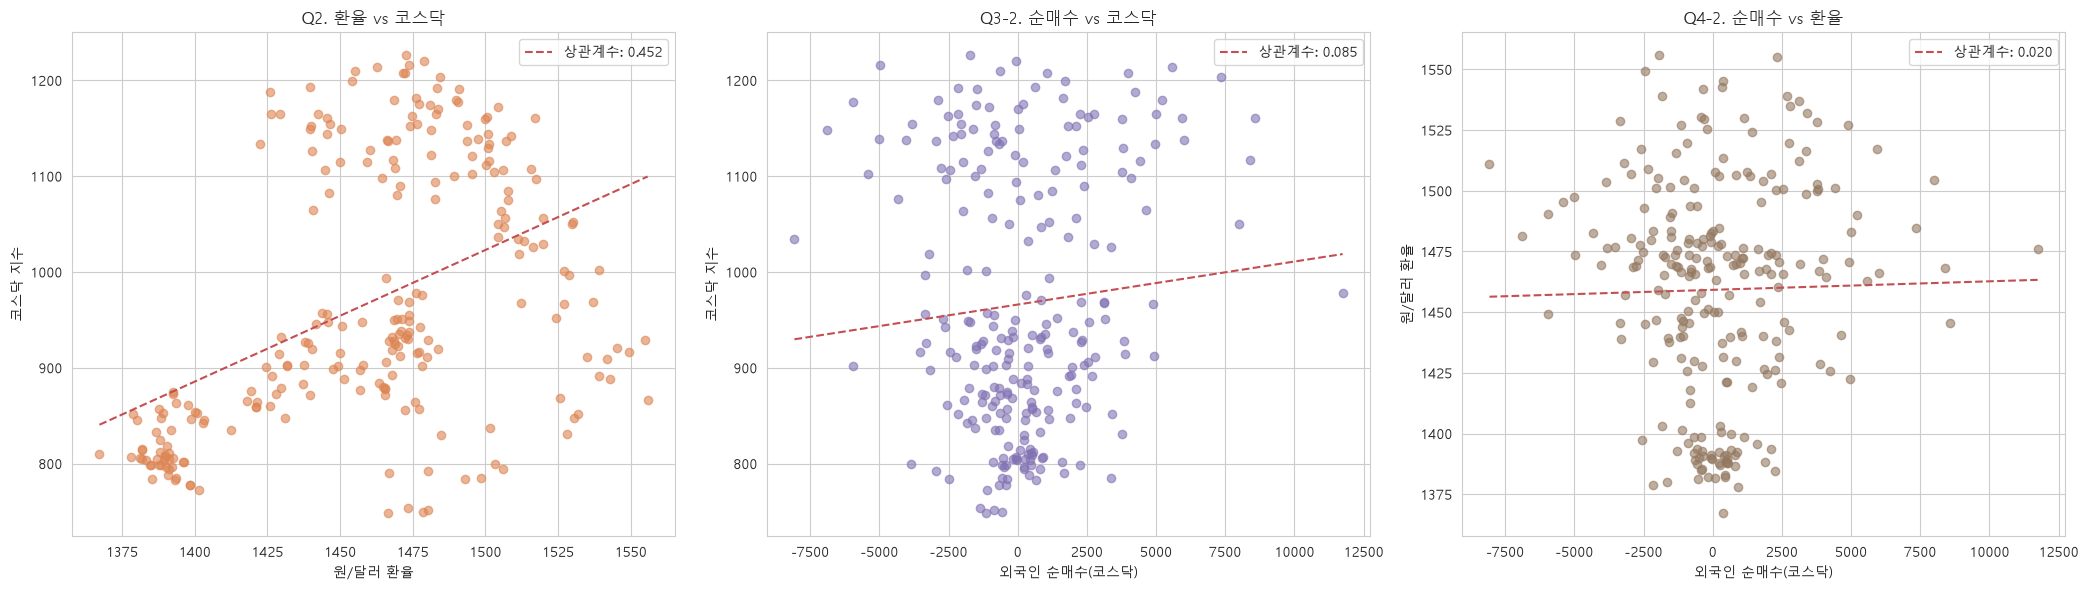

In [56]:
# 코스닥 관련 그래프 그리기 (Q2, Q3-2, Q4-2)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

plot_on_ax(axes[0], '원달러_종가', '코스닥지수', '원/달러 환율', '코스닥 지수', 'Q2. 환율 vs 코스닥', '#DD8452')
plot_on_ax(axes[1], '코스닥외국인순매수', '코스닥지수', '외국인 순매수(코스닥)', '코스닥 지수', 'Q3-2. 순매수 vs 코스닥', '#8172B3')
plot_on_ax(axes[2], '코스닥외국인순매수', '원달러_종가', '외국인 순매수(코스닥)', '원/달러 환율', 'Q4-2. 순매수 vs 환율', '#937860')

plt.tight_layout()
plt.show()